# LangChain ile bir RAG Uygulaması

LLM'lerin sağladığı en güçlü uygulamalardan biri, gelişmiş soru-cevap (Q&A) sohbet robotlarıdır. Bunlar, belirli kaynak bilgileriyle ilgili soruları yanıtlayabilen uygulamalardır. Bu uygulamalar, Retrieval Augmented Generation (RAG) olarak bilinen bir teknik kullanır. Bu eğitimde, yapılandırılmamış bir metin veri kaynağı üzerinde basit bir Q&A uygulamasının nasıl oluşturulacağı gösterilecektir.

# RAG (RETRIEVAL AUGMENTED GENERATION) NEDİR ?

2020 yılında bu terimi ortaya atan makalenin baş yazarı Patrick Lewis, yüzlerce makale ve düzinelerce ticari hizmette giderek büyüyen bir yöntem ailesini tanımlayan ve üretken yapay zekanın geleceğini temsil ettiğine inandığı bu hoş olmayan kısaltma için özür diledi.

**Makale** -->  https://arxiv.org/pdf/2005.11401

***Retrieval augmented generation (RAG)*** , doğal dil işleme (NLP) alanında, üretilen metnin kalitesini artırmak için arama tabanlı ve üretim tabanlı modellerin güçlü yönlerini birleştiren yenilikçi bir yaklaşımdır.

| Harf                           | Aşama                                           |  |
| ------------------------------ | ----------------------------------------------- | -------- |
| **R – Retrieve (Getir)**       | Yararlı bilgileri bul.                          |          |
| **A – Augment (Zenginleştir)** | Bulunan bilgileri yapay zekanın bilgisine ekle. |          |
| **G – Generate (Üret)**        | Daha iyi bir yanıt oluştur.                     |          |


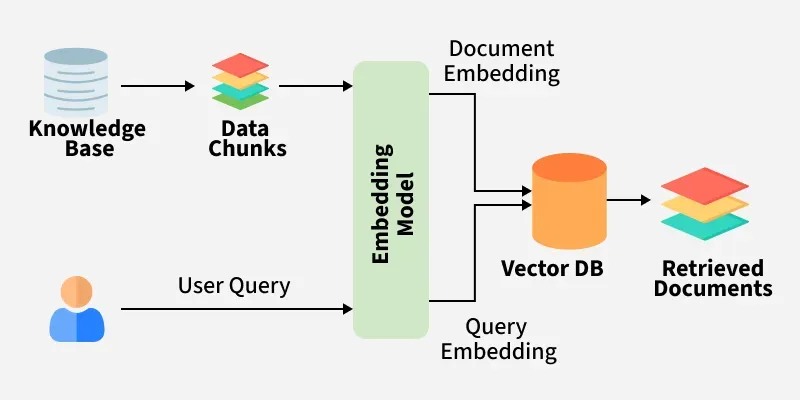

### 1. Knowledge Base (Bilgi Tabanı)
Bu, sistemin elinde bulunan tüm bilgilerin saklandığı ham veri deposudur.
Burada genellikle şu tür veriler bulunur:

- Dokümanlar (PDF, Word, Notlar, Web sayfaları vs.)

- Veri setleri

- Metin tabanlı içerikler (örneğin marka yorumları, teknik dökümanlar, blog yazıları, FAQ listeleri)

Bu aşamada veri henüz “ham” haldedir yani modelin anlayacağı biçimde işlenmemiştir.

### 2. Data Chunks (Veri Parçacıkları)

RAG sistemleri uzun metinlerle çalışmakta zorlandığı için, bilgi tabanı küçük parçalara (chunk) bölünür.
Her “chunk”, birkaç cümle ya da paragraf uzunluğunda olur.
Bunun amacı:

- Modelin dikkatini küçük, anlamlı birimlere odaklamak,

- Daha doğru benzerlik araması yapmak,

- Performansı artırmak.

Bu işlem sırasında genellikle “text splitting” stratejileri kullanılır (örneğin LangChain’de RecursiveCharacterTextSplitter).

### 3. Embedding Model (Gömme Modeli)

Bu model, hem bilgi tabanındaki veri parçacıklarını hem de kullanıcı sorgusunu vektör uzayına dönüştürür.

- Her metin parçası (chunk) için bir document embedding (doküman vektörü) oluşturulur.

- Kullanıcının sorduğu soru için bir query embedding (sorgu vektörü) oluşturulur.

Bu embedding’ler sayılardan oluşan yüksek boyutlu temsillerdir (örneğin 768 boyutlu bir vektör).
Amaç: Anlamsal benzerlikleri sayısal olarak ölçebilmek.
Bu aşamada genellikle Sentence Transformers, OpenAI Embeddings (text-embedding-3-large), Instructor XL, ya da E5 gibi modeller kullanılır.

### 4. Vector DB (Vektör Veritabanı)

Oluşturulan tüm doküman embedding’leri bu veritabanında saklanır.
Bu veritabanı, anlamsal arama (semantic search) yapabilecek özel bir yapıya sahiptir.

**Klasik ilişkisel veri tabanlarından farkı:**

- Burada metinler değil, vektörler saklanır.

- Benzerlik sorguları “string eşleşmesiyle” değil, cosine similarity / Euclidean distance gibi matematiksel ölçütlerle yapılır.

**Popüler vektör veritabanları:**

Chroma, FAISS, Pinecone, Weaviate, Milvus, Qdrant

### 5. Query Embedding (Sorgu Gömmesi)

Kullanıcının yazdığı “User Query”, örneğin:

“Chatbot'larda RAG sistemin önemi nedir?”

- Embedding model bu sorguyu da bir vektöre dönüştürür.

- Bu vektör, veri tabanındaki tüm doküman vektörleriyle karşılaştırılır.

Amaç:Kullanıcının sorduğu şeyle en çok benzer anlamı taşıyan doküman parçalarını bulmak.

## RAG hangi sorunları çözer?



1.   Factual Inaccuracies and Hallucinations (Gerçeklere Aykırı Bilgiler ve Halüsinasyonlar)
2.   Outdated Information (Güncel Olmayan Bilgiler)
3. Contextual Relevance (Bağlamsal Alaka)
4. Domain Specific Knowledge (Alana Özgü Bilgi)
5. Cost and Efficiency (Maliyet ve Verimlilik)
6. Scalability Across Domains (Alanlar Arası Ölçeklenebilirlik)




##  Kurulum

Gerekli kütüphaneleri yükleyelim:

In [ ]:
!pip install -q langchain langchain-google-genai langchain-community langchain-chroma \
    chromadb sentence-transformers datasets langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4

In [ ]:
import os
from google.colab import userdata

# Secret'tan API key'i çek
api_key = userdata.get("GEMINI_API_KEY")

# Environment variable olarak set et
os.environ["GEMINI_API_KEY"] = api_key

print("API key başarıyla yüklendi!")

API key başarıyla yüklendi!


---
##  Veri Yükleme — HuggingFace'den Veri Çekme

RAG'ın ilk adımı: **bilgi kaynağımızı** elde etmek.

HuggingFace Datasets kütüphanesi ile binlerce hazır datasete erişebilirsiniz.
Biz burada bir **Türkçe Wikipedia** dataset'i kullanacağız.

### RAG Neden Veri İster?
LLM'ler eğitim verisiyle sınırlıdır. RAG sayesinde:
-  Güncel bilgiye erişim sağlarız
-  Domain-specific (alana özel) bilgi ekleriz
-  Halüsinasyonları azaltırız

In [ ]:
from datasets import load_dataset

# HuggingFace'den Türkçe Wikipedia verisini çekelim
# (küçük bir subset alıyoruz, tamamı çok büyük)
dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.tr",       # Türkçe Wikipedia — Kasım 2023 dump
    split="train",
    streaming=True        # Tamamını indirmeden stream edelim
)

# İlk 50 makaleyi alalım (demo için yeterli)
articles = []
for i, item in enumerate(dataset):
    if i >= 50:
        break
    articles.append({
        "title": item["title"],
        "text": item["text"]
    })

print(f" {len(articles)} makale yüklendi!")
print(f"\n Örnek makale başlığı: {articles[0]['title']}")
print(f" İlk 300 karakter:\n{articles[0]['text'][:300]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

 50 makale yüklendi!

 Örnek makale başlığı: Cengiz Han
 İlk 300 karakter:
Cengiz Han (doğum adıyla Temuçin,  – 18 Ağustos 1227), Moğol İmparatorluğu'nun kurucusu ve ilk Kağanı olan Moğol komutan ve hükümdardır. Hükümdarlığı döneminde gerçekleştirdiği hiçbir savaşı kaybetmeyen Cengiz Han, dünya tarihinin en büyük askeri liderlerinden birisi olarak kabul edilmektedir. 13. y...


In [ ]:
# Makalelerin uzunluklarına bakalım
lengths = [len(a['text']) for a in articles]
print(f" Ortalama makale uzunluğu: {sum(lengths)//len(lengths):,} karakter")
print(f" En kısa: {min(lengths):,} | En uzun: {max(lengths):,} karakter")


 Ortalama makale uzunluğu: 22,252 karakter
 En kısa: 189 | En uzun: 156,337 karakter


---
## 2 Splitting (Bölme) — Dokümanları Parçalara Ayırma

### Neden Bölüyoruz?
- LLM'lerin **context window**'u sınırlıdır
- Tüm dokümanı göndermek **maliyetli** ve **verimsiz**
- Küçük parçalar → daha **isabetli** retrieval

### Splitting Stratejileri
| Strateji | Açıklama | Ne Zaman? |
|----------|----------|-----------|
| **Character** | Sabit karakter sayısı | Basit metinler |
| **Recursive** | Paragraf → Cümle → Kelime | Genel amaçlı  |
| **Token-based** | Token sayısına göre | LLM-optimize |
| **Semantic** | Anlam bazlı | İleri seviye |

In [ ]:
!pip install -q langchain langchain-text-splitters

In [ ]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

from langchain_core.documents import Document

documents = [
    Document(
        page_content=article["text"],
        metadata={"title": article["title"], "source": "wikipedia-tr"}
    )
    for article in articles
]

print(f" {len(documents)} doküman oluşturuldu")
print(f" Örnek metadata: {documents[0].metadata}")

 50 doküman oluşturuldu
 Örnek metadata: {'title': 'Cengiz Han', 'source': 'wikipedia-tr'}


In [ ]:
# ---- Yöntem 2: Recursive Character Splitting  ----
# Bu yöntem metni doğal sınırlardan böler:
# Önce paragraflardan (\n\n) → sonra satırlardan (\n) → sonra cümlelerden (.) → son çare kelimelerden

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,            # Her chunk max 500 karakter
    chunk_overlap=50,          # Bağlam kaybını önlemek için 50 karakter örtüşme
    separators=["\n\n", "\n", ". ", " ", ""],  # Bölme öncelik sırası
    length_function=len
)

recursive_chunks = recursive_splitter.split_documents(documents[:3])
print(f" Recursive splitting: {len(recursive_chunks)} parça oluştu")

 Recursive splitting: 355 parça oluştu


---
## Chunking — Detaylı Parçalama Stratejileri

Chunk boyutu RAG performansını **doğrudan** etkiler:

```
Küçük chunk (100-300)  → Hassas retrieval ama bağlam kaybı
Orta chunk (300-800)   → Dengeli — çoğu use case için ideal
Büyük chunk (800-2000) → Geniş bağlam ama gürültülü retrieval
```

### Chunk Overlap Neden Önemli?
Overlap olmadan bir cümle ortasından bölünebilir → bilgi kaybı yaşanır.

In [ ]:
# Farklı chunk boyutlarını deneyelim
test_doc = documents[0]  # Tek bir makale üzerinde test

for chunk_size in [200, 500, 1000]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size * 0.1)  # %10 overlap
    )
    chunks = splitter.split_documents([test_doc])
    avg_len = sum(len(c.page_content) for c in chunks) // len(chunks)
    print(f"Chunk size={chunk_size:>5} → {len(chunks):>3} parça | Ort. uzunluk: {avg_len} karakter")

Chunk size=  200 → 617 parça | Ort. uzunluk: 177 karakter
Chunk size=  500 → 278 parça | Ort. uzunluk: 395 karakter
Chunk size= 1000 → 153 parça | Ort. uzunluk: 704 karakter


In [ ]:
# ---- ASIL CHUNKING: Tüm dokümanları parçalayalım ----
# Bu chunk'ları RAG pipeline'ında kullanacağız

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

all_chunks = text_splitter.split_documents(documents)

print(f" Toplam {len(documents)} doküman → {len(all_chunks)} chunk'a bölündü")
print(f" Ortalama chunk boyutu: {sum(len(c.page_content) for c in all_chunks)//len(all_chunks)} karakter")

 Toplam 50 doküman → 3415 chunk'a bölündü
 Ortalama chunk boyutu: 326 karakter


---
## 4 Embedding & Indexing — Vektörlere Dönüştürme

### Embedding Nedir?
Metni **sayısal vektörlere** dönüştürme işlemidir. Bu sayede:
- Metinler arası **benzerlik** hesaplanabilir
- Vektör veritabanında **aranabilir** hale gelir

```
"Ankara Türkiye'nin başkentidir" → [0.12, -0.45, 0.78, ..., 0.33]  (384 boyutlu vektör)
"İstanbul en kalabalık şehirdir" → [0.15, -0.41, 0.71, ..., 0.29]  (benzer vektör!)
"Kediler sevimlidir"             → [0.89, 0.12, -0.56, ..., -0.44] (farklı vektör)
```

### Indexing Nedir?
Embedding'leri **organize** edip **hızlı arama** yapılabilir hale getirmektir.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
import numpy as np

# Embedding modeli — çok dilli, Türkçe destekli
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}  # Cosine similarity için normalize
)

print("Embedding modeli yüklendi!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding modeli yüklendi!


In [ ]:
# Embedding nasıl çalışır?
test_texts = [
    "Ankara Türkiye'nin başkentidir",
    "Türkiye'nin başşehri Ankara'dır",     # Aynı anlam, farklı kelimeler
    "Kediler çok sevimli hayvanlardır"       # Tamamen farklı konu
]

test_embeddings = embedding_model.embed_documents(test_texts)

print(f"Vektör boyutu: {len(test_embeddings[0])} boyut")
print(f"İlk 10 değer: {test_embeddings[0][:10]}")

# Cosine similarity hesaplayalım
from numpy import dot
from numpy.linalg import norm

def cosine_sim(a, b):
    return dot(a, b) / (norm(a) * norm(b))

print(f"\n Benzerlik Skorları:")
print(f"  'Ankara başkent' vs 'Başşehir Ankara' → {cosine_sim(test_embeddings[0], test_embeddings[1]):.4f} (yüksek )")
print(f"  'Ankara başkent' vs 'Kediler sevimli'  → {cosine_sim(test_embeddings[0], test_embeddings[2]):.4f} (düşük )")

Vektör boyutu: 384 boyut
İlk 10 değer: [0.016483422368764877, 0.06924634426832199, -0.006089368835091591, 0.021969536319375038, -0.058512475341558456, -0.006238270550966263, 0.09102053195238113, -0.01231851615011692, 0.0020620867144316435, -0.021740375086665154]

 Benzerlik Skorları:
  'Ankara başkent' vs 'Başşehir Ankara' → 0.9091 (yüksek )
  'Ankara başkent' vs 'Kediler sevimli'  → 0.5527 (düşük )


---
##  Vector DB — ChromaDB ile Vektör Veritabanı

### Vector DB Nedir?
Vektörleri saklayan ve **benzerlik araması** yapabilen özel veritabanıdır.

### Popüler Vector DB'ler
| DB | Özellik |
|------|--------|
| **ChromaDB** | Hafif, kolay, local — öğrenmek için ideal  |
| **Pinecone** | Cloud-based, production-ready |
| **Weaviate** | Hybrid search, GraphQL |
| **FAISS** | Facebook'un kütüphanesi, çok hızlı |
| **Qdrant** | Rust-based, performanslı |

### İşlem Akışı
```
Chunk'lar → Embedding → Vektörler → ChromaDB'ye kayıt (Indexing)
```

In [ ]:
from langchain_chroma import Chroma

# ChromaDB'yi oluşturalım ve chunk'ları indexleyelim
# Bu adım: embedding + indexing + storage hepsini bir arada yapar

vectorstore = Chroma.from_documents(
    documents=all_chunks,          # Chunk'larımız
    embedding=embedding_model,     # Embedding modeli
    collection_name="wiki_tr",     # Koleksiyon adı
    persist_directory="./chroma_db" # Diske kaydetme (opsiyonel)
)

print(f"ChromaDB oluşturuldu!")
print(f" Toplam {vectorstore._collection.count()} vektör indexlendi")

ChromaDB oluşturuldu!
 Toplam 3415 vektör indexlendi


In [ ]:
# basit bir similarity search
query = "Cumhuriyet kaç yılına ilan edildi?"

results = vectorstore.similarity_search_with_score(query, k=3)

print(f" Sorgu: '{query}'\n")
for i, (doc, score) in enumerate(results, 1):
    print(f"--- Sonuç {i} (skor: {score:.4f}) ---")
    print(f" Kaynak: {doc.metadata.get('title', 'N/A')}")
    print(f" İçerik: {doc.page_content[:200]}...\n")

 Sorgu: 'Cumhuriyet kaç yılına ilan edildi?'

--- Sonuç 1 (skor: 0.4176) ---
 Kaynak: Mustafa Kemal Atatürk
 İçerik: . Anayasa Komisyonu'nun değişiklik ile ilgili rapor ve önergesi genel kurulun onayına sunuldu ve 29 Ekim 1923 Pazartesi akşamı saat 20.30'da milletvekillerinin alkışları ve "Yaşasın cumhuriyet!" nidal...

--- Sonuç 2 (skor: 0.4476) ---
 Kaynak: Edebiyat
 İçerik: . Osmanlı sarayı çevresinde, Fars edebiyatı'nın etkisiyle üretilen klasik edebiyat denilen divan edebiyatı ağır basarken halk arasında, sözlü gelenek uzun bir zaman devam etti....

--- Sonuç 3 (skor: 0.4646) ---
 Kaynak: Türkiye
 İçerik: 12. Cumhurbaşkanı Recep Tayyip Erdoğan şu anda devlet ve hükümet başkanı olarak görev yapıyor. Kemal Kılıçdaroğlu, Türkiye'nin ana muhalefet lideridir. Devlet Bahçeli, Türkiye Büyük Millet Meclisi Geç...



---
##  Retriever — İlgili Dokümanları Getirme

### Retriever Nedir?
Kullanıcının sorusuna **en ilgili** doküman parçalarını bulan bileşendir.

### Retriever Türleri
- **Similarity Search** — Cosine similarity ile en yakın vektörler
- **MMR (Maximum Marginal Relevance)** — Benzer ama **çeşitli** sonuçlar
- **Threshold** — Minimum skor eşiği ile filtreleme

```
Kullanıcı Sorusu → Embedding → Vector DB'de Arama → En İlgili K Chunk
```

In [ ]:
# ---- Basit Similarity Retriever ----
retriever_simple = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}       # En ilgili 3 chunk getir
)

query = "Atatürk kaç yılında Samsuna çıktı?"
docs = retriever_simple.invoke(query)

print(f" Sorgu: '{query}'")
print(f" {len(docs)} doküman bulundu:\n")
for i, doc in enumerate(docs, 1):
    print(f"  [{i}] {doc.metadata.get('title', 'N/A')} — {doc.page_content[:150]}...")

 Sorgu: 'Atatürk kaç yılında Samsuna çıktı?'
 3 doküman bulundu:

  [1] Mustafa Kemal Atatürk — Samsun'a çıkışı...
  [2] Mustafa Kemal Atatürk — Atatürk'ün Kemal yerine kullandığı adla ilgili olarak Atatürk hayatta iken Anadolu Ajansı tarafından şöyle bir açıklama yapılmıştır: "İstihbaratımıza ...
  [3] Mustafa Kemal Atatürk — Dünyanın çeşitli ülkelerinde Atatürk anısına anıtlar dikilmiştir...


---
##  Query + LLM — Gemini ile Cevap Üretme

### RAG'ın Son Adımı
Retriever'dan gelen dokümanları **context** olarak LLM'e verip cevap ürettiriyoruz.

```
Kullanıcı Sorusu + Retrieve Edilen Dokümanlar → Prompt → Gemini → Cevap
```

### Neden Sadece LLM Yetmez?
- LLM'in bilgisi **eğitim tarihiyle** sınırlı
- RAG ile **güncel** ve **özel** bilgiyi enjekte ediyoruz
- Cevap **kaynaklara dayalı** oluyor → güvenilirlik artar

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini LLM'i başlatalım
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",     # Hızlı ve verimli model
    temperature=0.3,               # Düşük temperature → daha tutarlı cevaplar
    max_output_tokens=1024
)


In [ ]:
# RAG Prompt Template
from langchain_core.prompts import PromptTemplate

rag_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""
Sen yardımcı bir asistansın. Aşağıdaki bağlam bilgisini kullanarak soruyu Türkçe olarak cevapla.

Kurallar:
- SADECE verilen bağlam bilgisini kullan
- Bağlamda bilgi yoksa "Bu bilgi mevcut kaynaklarda bulunamadı" de
- Cevabını kısa ve öz tut
- Kaynak makale başlığını belirt

Bağlam:
{context}

Soru: {question}

Cevap:"""
)

print(" RAG prompt şablonu hazır!")

 RAG prompt şablonu hazır!


In [ ]:
# Manuel RAG — adım adım görelim
question = "Türkiye hakkında ne biliyorsun?"

# Adım 1: Retrieve
retrieved_docs = retriever_simple.invoke(question)
print(f"Adım 1 — {len(retrieved_docs)} doküman retrieve edildi")

# Adım 2: Context oluştur
context = "\n\n".join([
    f"[Kaynak: {doc.metadata.get('title', 'N/A')}]\n{doc.page_content}"
    for doc in retrieved_docs
])
print(f" Adım 2 — Context oluşturuldu ({len(context)} karakter)")

# Adım 3: Prompt oluştur
final_prompt = rag_prompt.format(context=context, question=question)
print(f" Adım 3 — Prompt hazır ({len(final_prompt)} karakter)")

# Adım 4: LLM'e gönder
response = llm.invoke(final_prompt)
print(f"\n Adım 4 — Gemini Cevabı:")
print("=" * 50)
print(response.content)

Adım 1 — 3 doküman retrieve edildi
 Adım 2 — Context oluşturuldu (647 karakter)
 Adım 3 — Prompt hazır (979 karakter)

 Adım 4 — Gemini Cevabı:
Selçuklu Türklerinin 1071 yılında Bizans'a karşı kazandığı Malazgirt Meydan Muharebesi ile Anadolu'daki Bizans üstünlüğü büyük ölçüde kırılarak Anadolu, kısa süre içerisinde Selçuklulara bağlı Türk beyleri tarafından ele geçirildi ve Anadolu toprakları üzerinde İslamlaşma ve Türkleşme faaliyetleri başladı. (Kaynak: Türkiye)
